<a href="https://colab.research.google.com/github/emiliomulet-commits/procuredatawhitepaper/blob/main/basededatos_menorcamar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import random
from google.colab import drive
import os

# 1. Conectar con Google Drive
drive.mount('/content/drive')

# 2. Definir ruta de guardado
path = '/content/drive/My Drive/MenorcaMar_Data/'
if not os.path.exists(path):
    os.makedirs(path)

# 3. Motor de generación sintética avanzada
def generar_usuarios_menorca_mar(n_total=2300):
    nacionalidades_config = {
        'Española': 100, 'Alemana': 100, 'Británica': 100, 'Francesa': 100,
        'Holandesa': 100, 'Belga': 100, 'Luxemburguesa': 100, 'Italiana': 100,
        'Danesa': 100, 'Finlandesa': 100, 'Sueca': 100, 'Polaca': 100,
        'Checa': 50, 'Eslovaca': 50, 'Húngara': 100, 'Rusa': 100,
        'Canadiense': 100, 'Estadounidense': 500, 'Portuguesa': 300
    }

    salud_opciones = [
        'Hipertensión arterial controlada', 'Tendencia alta a la cinetosis (mareo)',
        'Arritmia cardíaca leve y anticoagulado', 'Diabetes Tipo II',
        'Asma bronquial', 'Alergia solar severa', 'Embarazo', 'Saludable'
    ]

    data = []
    current_id = 1

    for nac, cantidad in nacionalidades_config.items():
        for _ in range(cantidad):
            edad = random.randint(18, 80)
            peso = random.randint(50, 125)
            salud = random.choice(salud_opciones)

            # Lógica One Health & IA de Posicionamiento
            posicion = 'Centro' if peso > 95 or edad > 65 else random.choice(['Proa', 'Popa', 'Centro'])
            riesgo = 'Alto' if edad > 70 or 'Arritmia' in salud else 'Bajo'
            if 'mareo' in salud: posicion = 'Popa (Baja)'

            # Lógica de Fototipo
            fototipo = random.choice(['I', 'II']) if nac in ['Danesa', 'Sueca', 'Británica'] else random.choice(['III', 'IV'])
            spf = '50+' if fototipo in ['I', 'II'] else '30'

            data.append({
                'id': current_id,
                'nombre': f'Usuario_{current_id}',
                'apellido': f'Apellido_{nac}_{current_id}',
                'nacionalidad': nac,
                'edad': edad,
                'peso_kg': peso,
                'condicion_salud': salud,
                'posicion_recomendada': posicion,
                'protocolo_riesgo': riesgo,
                'fototipo': fototipo,
                'spf_recomendado': spf,
                'frecuencia_crema_min': 45 if fototipo == 'I' else 90,
                'instruccion_monitor': f'Vigilar hidratación y exposición de {nac}'
            })
            current_id += 1

    return pd.DataFrame(data)

# 4. Ejecutar y Guardar
df_final = generar_usuarios_menorca_mar()
filename = path + 'dataset_menorca_mar_consolidado.csv'
df_final.to_csv(filename, index=False, encoding='utf-8-sig')

print(f'¡Éxito! Se han generado {len(df_final)} registros.')
print(f'El archivo se ha guardado en: {filename}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
¡Éxito! Se han generado 2400 registros.
El archivo se ha guardado en: /content/drive/My Drive/MenorcaMar_Data/dataset_menorca_mar_consolidado.csv


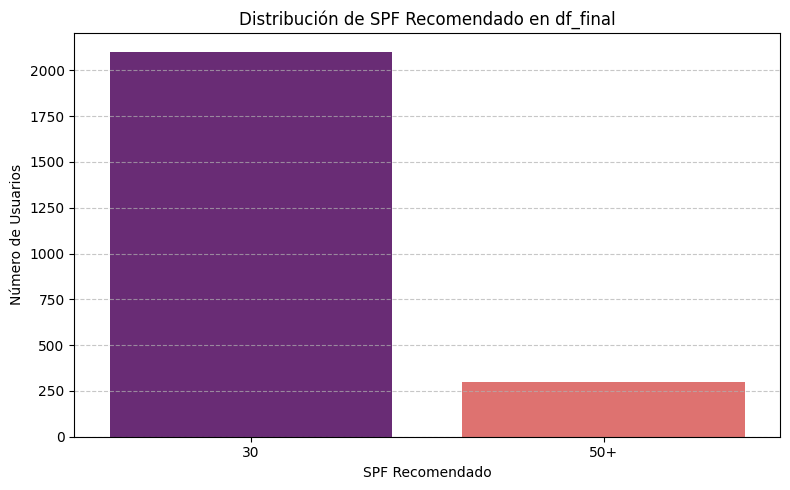

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=df_final, x='spf_recomendado', palette='magma', hue='spf_recomendado', legend=False)
plt.title('Distribución de SPF Recomendado en df_final')
plt.xlabel('SPF Recomendado')
plt.ylabel('Número de Usuarios')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

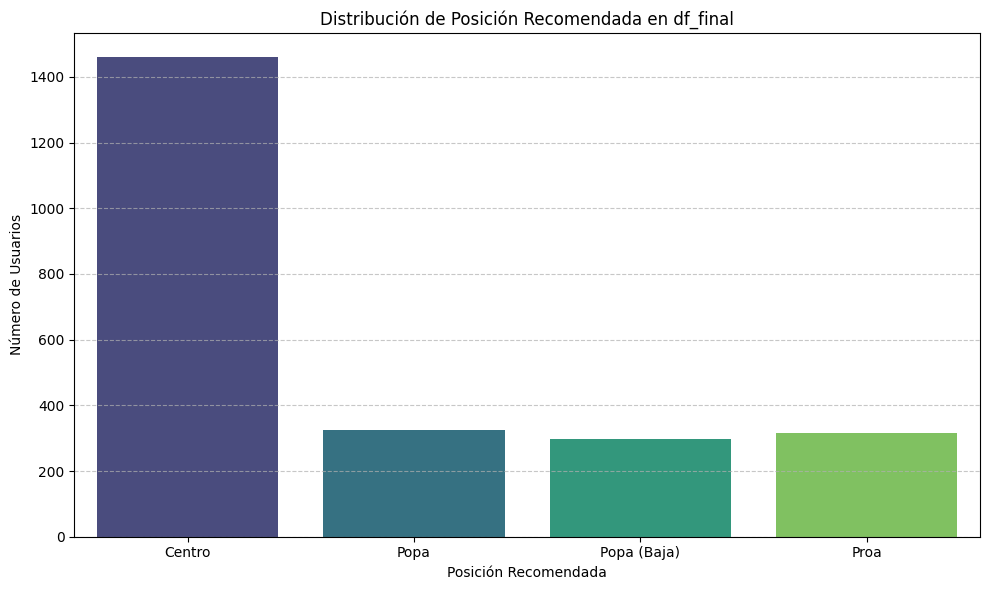

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=df_final, x='posicion_recomendada', palette='viridis', hue='posicion_recomendada', legend=False)
plt.title('Distribución de Posición Recomendada en df_final')
plt.xlabel('Posición Recomendada')
plt.ylabel('Número de Usuarios')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

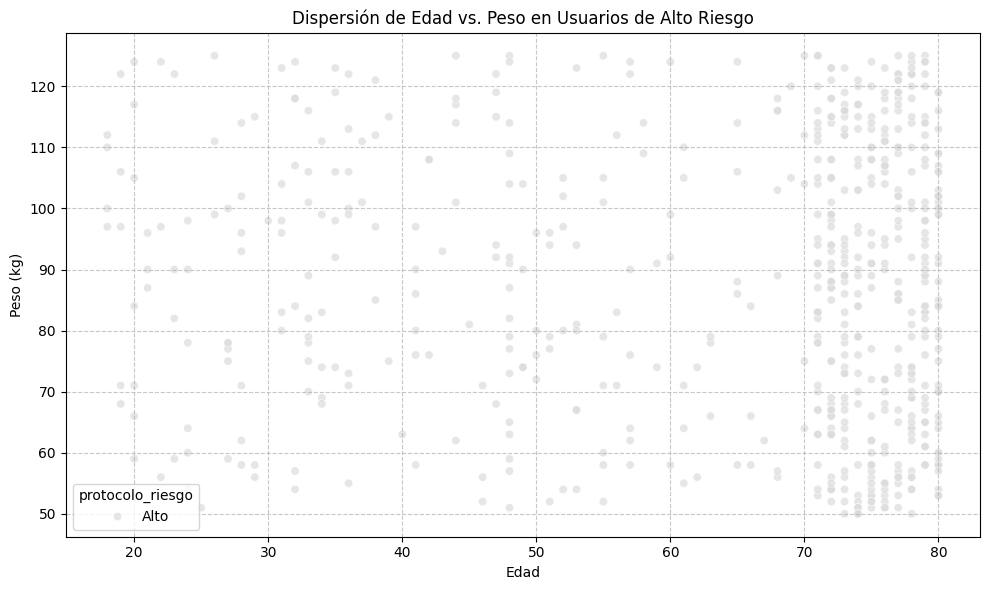

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_alto_riesgo, x='edad', y='peso_kg', hue='protocolo_riesgo', palette='coolwarm', alpha=0.7)
plt.title('Dispersión de Edad vs. Peso en Usuarios de Alto Riesgo')
plt.xlabel('Edad')
plt.ylabel('Peso (kg)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [30]:
print('Distribución de SPF Recomendado en df_final:')
display(df_final['spf_recomendado'].value_counts())

print('\nDistribución de SPF Recomendado en df_alto_riesgo:')
display(df_alto_riesgo['spf_recomendado'].value_counts())

Distribución de SPF Recomendado en df_final:


,count
spf_recomendado,
30,2100
50+,300



Distribución de SPF Recomendado en df_alto_riesgo:


,count
spf_recomendado,
30,547
50+,76


Estos resultados te permitirán comparar directamente la proporción de usuarios que reciben SPF '30' y SPF '50+' en el conjunto de datos completo frente al grupo de alto riesgo.

Valores únicos de 'fototipo' en df_alto_riesgo: ['IV' 'III' 'II' 'I']
Valores únicos de 'spf_recomendado' en df_alto_riesgo: ['30' '50+']


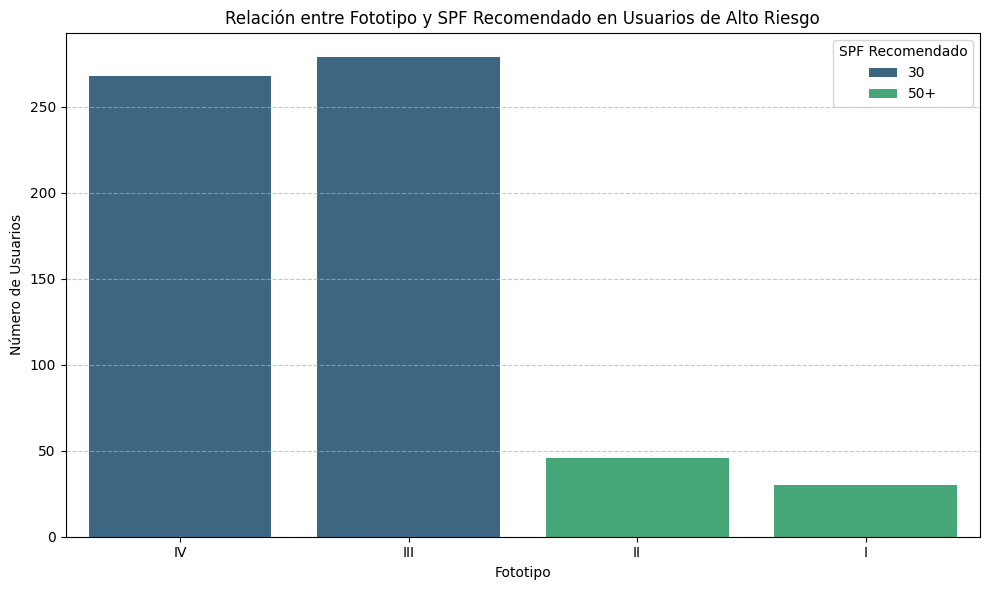

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Verificar los valores únicos en df_alto_riesgo
print("Valores únicos de 'fototipo' en df_alto_riesgo:", df_alto_riesgo['fototipo'].unique())
print("Valores únicos de 'spf_recomendado' en df_alto_riesgo:", df_alto_riesgo['spf_recomendado'].unique())

# Crear el gráfico de barras agrupado para df_alto_riesgo
plt.figure(figsize=(10, 6))
sns.countplot(data=df_alto_riesgo, x='fototipo', hue='spf_recomendado', palette='viridis')
plt.title('Relación entre Fototipo y SPF Recomendado en Usuarios de Alto Riesgo')
plt.xlabel('Fototipo')
plt.ylabel('Número de Usuarios')
plt.legend(title='SPF Recomendado')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Este gráfico visualiza la misma relación que antes, pero filtrada solo para el grupo de 'Alto Riesgo'. Podrás observar si la distribución de fototipos y las recomendaciones de SPF cambian o se mantienen consistentes dentro de este segmento específico.

Valores únicos de 'fototipo': ['IV' 'III' 'I' 'II']
Valores únicos de 'spf_recomendado': ['30' '50+']


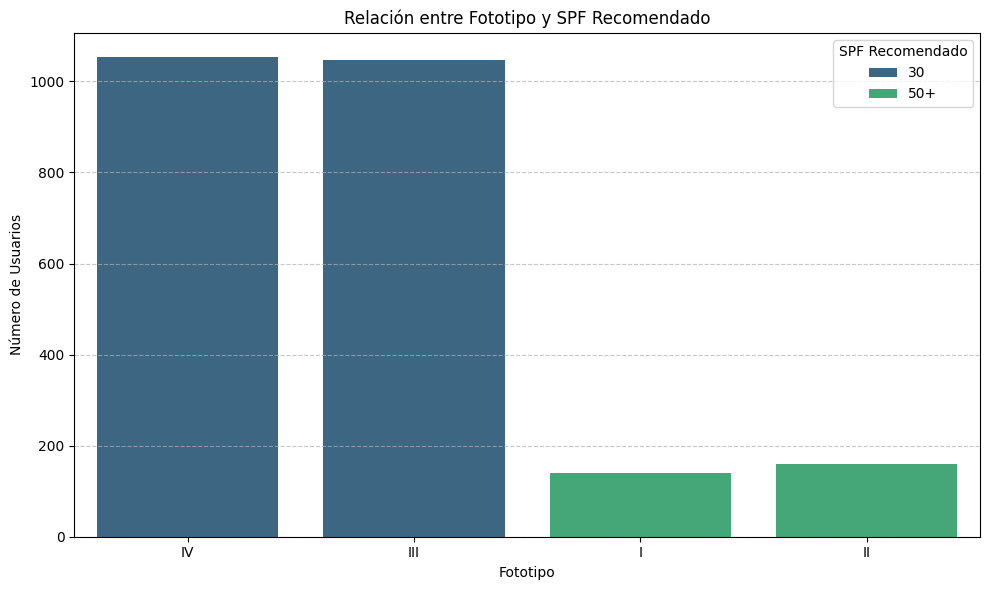

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener los valores únicos para 'fototipo' y 'spf_recomendado' para confirmar
print("Valores únicos de 'fototipo':", df_final['fototipo'].unique())
print("Valores únicos de 'spf_recomendado':", df_final['spf_recomendado'].unique())

# Crear el gráfico de barras agrupado
plt.figure(figsize=(10, 6))
sns.countplot(data=df_final, x='fototipo', hue='spf_recomendado', palette='viridis')
plt.title('Relación entre Fototipo y SPF Recomendado')
plt.xlabel('Fototipo')
plt.ylabel('Número de Usuarios')
plt.legend(title='SPF Recomendado')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Este gráfico muestra cómo el factor de protección solar (SPF) recomendado se asigna a cada fototipo de piel. Como se observó en la lógica de generación de datos, los fototipos I y II reciben SPF '50+', mientras que los fototipos III y IV reciben SPF '30'.

In [24]:
print('Distribución de Fototipo en df_alto_riesgo:')
display(df_alto_riesgo['fototipo'].value_counts())

Distribución de Fototipo en df_alto_riesgo:


,count
fototipo,
III,279
IV,268
II,46
I,30


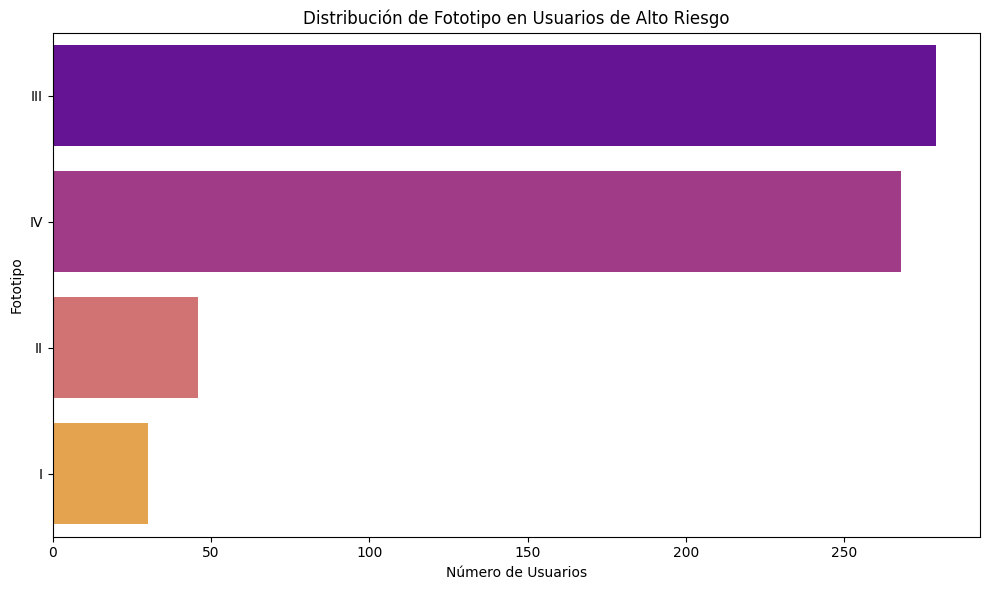

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la frecuencia de cada fototipo en df_alto_riesgo
fototipo_alto_riesgo_counts = df_alto_riesgo['fototipo'].value_counts().reset_index()
fototipo_alto_riesgo_counts.columns = ['Fototipo', 'Frecuencia']

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='Frecuencia', y='Fototipo', data=fototipo_alto_riesgo_counts, palette='plasma', hue='Fototipo', legend=False)
plt.title('Distribución de Fototipo en Usuarios de Alto Riesgo')
plt.xlabel('Número de Usuarios')
plt.ylabel('Fototipo')
plt.tight_layout()
plt.show()

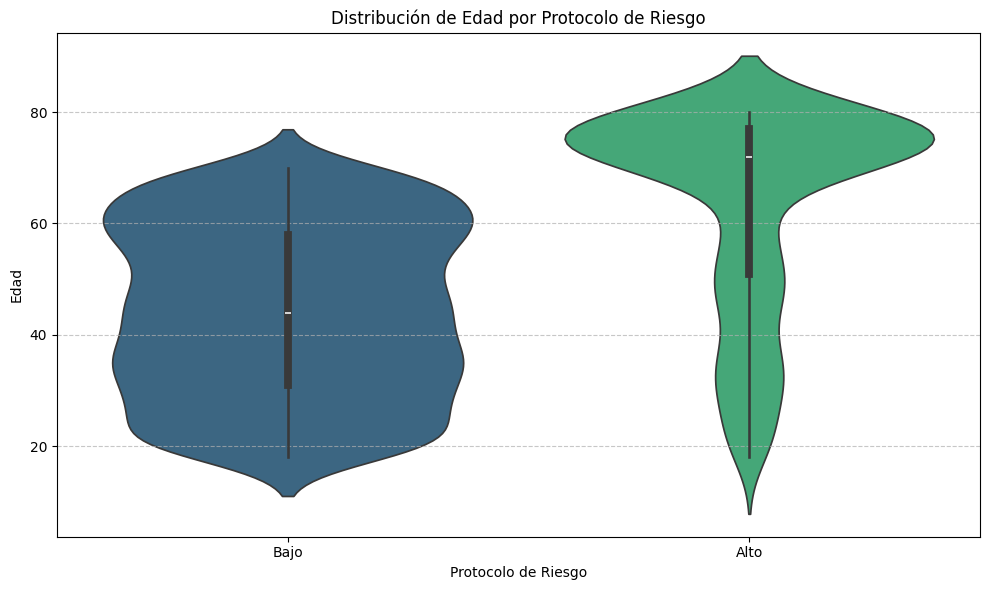

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.violinplot(x='protocolo_riesgo', y='edad', data=df_final, palette='viridis', hue='protocolo_riesgo', legend=False)
plt.title('Distribución de Edad por Protocolo de Riesgo')
plt.xlabel('Protocolo de Riesgo')
plt.ylabel('Edad')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

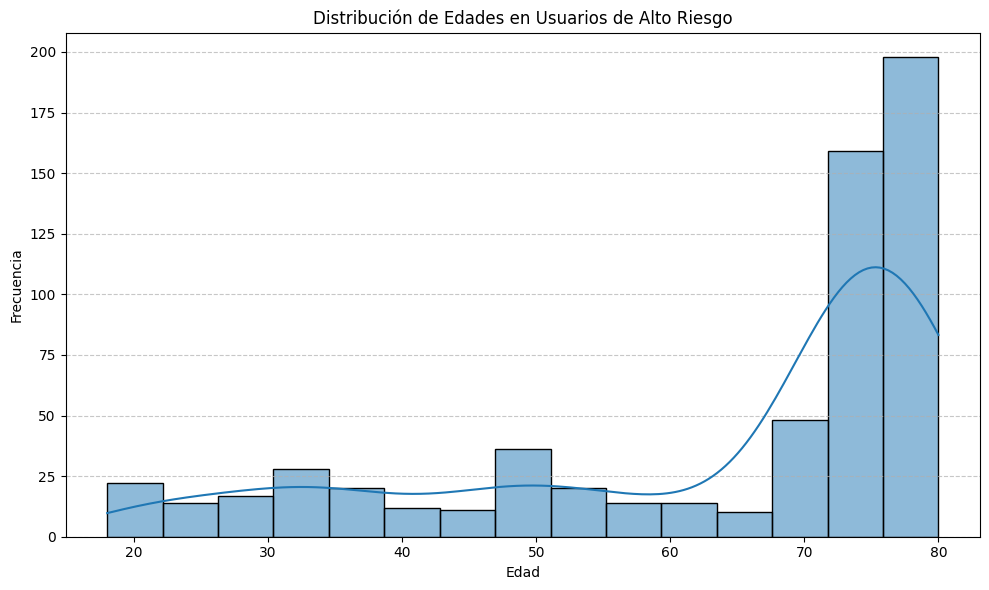

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_alto_riesgo['edad'], bins=15, kde=True)
plt.title('Distribución de Edades en Usuarios de Alto Riesgo')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [19]:
print('Distribución de Condiciones de Salud en df_alto_riesgo:')
display(df_alto_riesgo['condicion_salud'].value_counts())

Distribución de Condiciones de Salud en df_alto_riesgo:


,count
condicion_salud,
Arritmia cardíaca leve y anticoagulado,284
Alergia solar severa,53
Hipertensión arterial controlada,52
Tendencia alta a la cinetosis (mareo),51
Asma bronquial,50
Embarazo,48
Saludable,43
Diabetes Tipo II,42


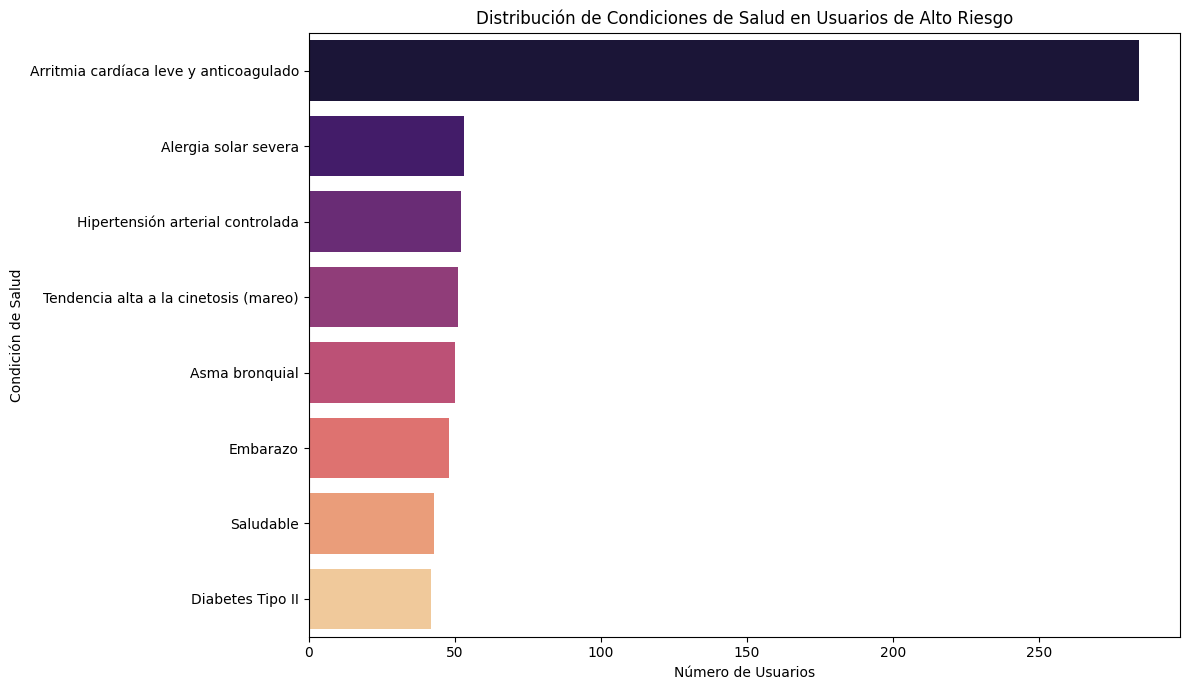

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la frecuencia de cada condición de salud en df_alto_riesgo
salud_alto_riesgo_counts = df_alto_riesgo['condicion_salud'].value_counts().reset_index()
salud_alto_riesgo_counts.columns = ['Condicion_Salud', 'Frecuencia']

# Crear el gráfico de barras
plt.figure(figsize=(12, 7))
sns.barplot(x='Frecuencia', y='Condicion_Salud', data=salud_alto_riesgo_counts, palette='magma', hue='Condicion_Salud', legend=False)
plt.title('Distribución de Condiciones de Salud en Usuarios de Alto Riesgo')
plt.xlabel('Número de Usuarios')
plt.ylabel('Condición de Salud')
plt.tight_layout()
plt.show()

In [21]:
df_alto_riesgo = df_final[df_final['protocolo_riesgo'] == 'Alto']
display(df_alto_riesgo.head())

,id,nombre,apellido,nacionalidad,edad,peso_kg,condicion_salud,posicion_recomendada,protocolo_riesgo,fototipo,spf_recomendado,frecuencia_crema_min,instruccion_monitor
2,3,Usuario_3,Apellido_Española_3,Española,20,117,Arritmia cardíaca leve y anticoagulado,Centro,Alto,IV,30,90,Vigilar hidratación y exposición de Española
4,5,Usuario_5,Apellido_Española_5,Española,80,109,Tendencia alta a la cinetosis (mareo),Popa (Baja),Alto,III,30,90,Vigilar hidratación y exposición de Española
5,6,Usuario_6,Apellido_Española_6,Española,72,99,Tendencia alta a la cinetosis (mareo),Popa (Baja),Alto,III,30,90,Vigilar hidratación y exposición de Española
7,8,Usuario_8,Apellido_Española_8,Española,53,123,Arritmia cardíaca leve y anticoagulado,Centro,Alto,III,30,90,Vigilar hidratación y exposición de Española
10,11,Usuario_11,Apellido_Española_11,Española,77,55,Diabetes Tipo II,Centro,Alto,III,30,90,Vigilar hidratación y exposición de Española


In [18]:
print(f"Número de usuarios con protocolo de riesgo 'Alto': {len(df_alto_riesgo)}")

Número de usuarios con protocolo de riesgo 'Alto': 623


In [15]:
display(df_final['peso_kg'].describe())

,peso_kg
count,2400.000000
mean,87.930833
std,22.194736
min,50.000000
25%,69.000000
50%,89.000000
75%,107.000000
max,125.000000


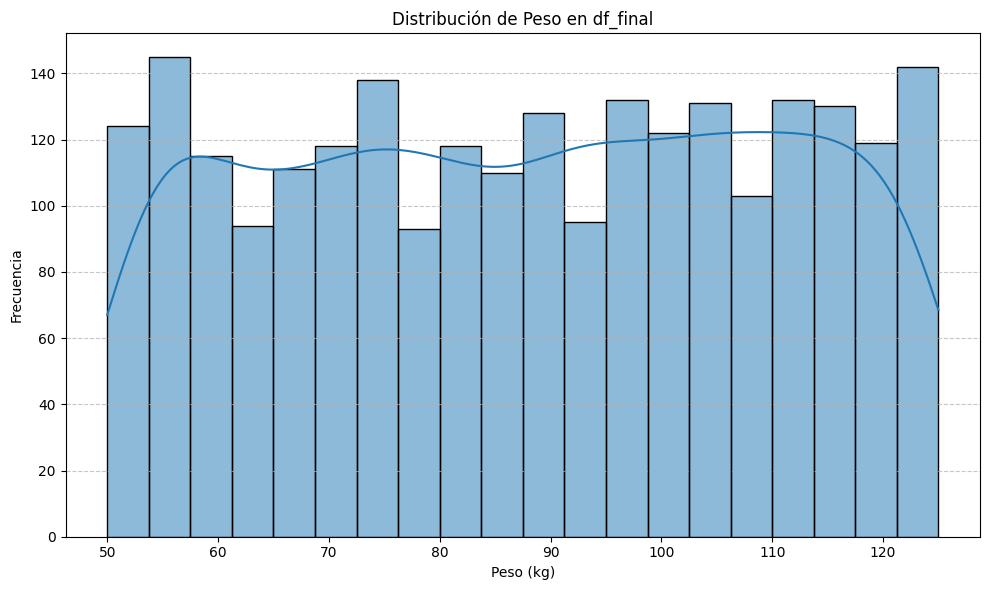

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_final['peso_kg'], bins=20, kde=True)
plt.title('Distribución de Peso en df_final')
plt.xlabel('Peso (kg)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [13]:
display(df_final['condicion_salud'].value_counts())

,count
condicion_salud,
Hipertensión arterial controlada,315
Embarazo,315
Alergia solar severa,309
Diabetes Tipo II,302
Tendencia alta a la cinetosis (mareo),298
Asma bronquial,292
Saludable,285
Arritmia cardíaca leve y anticoagulado,284


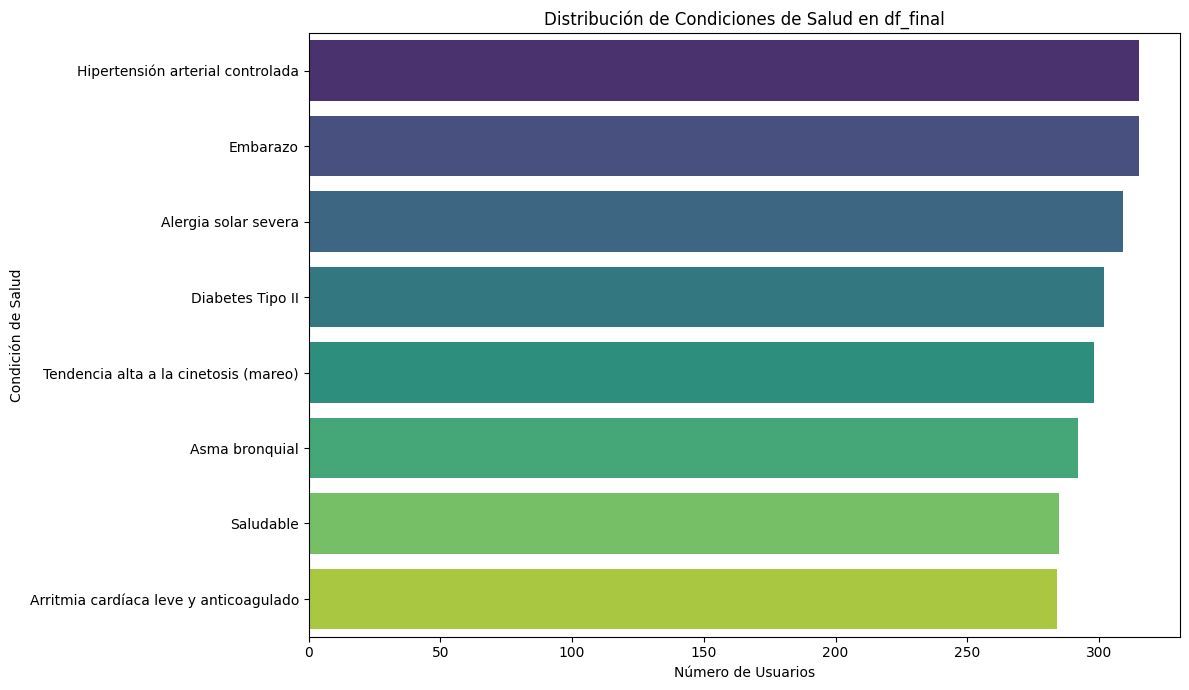

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la frecuencia de cada condición de salud
salud_counts = df_final['condicion_salud'].value_counts().reset_index()
salud_counts.columns = ['Condicion_Salud', 'Frecuencia']

# Crear el gráfico de barras
plt.figure(figsize=(12, 7))
sns.barplot(x='Frecuencia', y='Condicion_Salud', data=salud_counts, palette='viridis', hue='Condicion_Salud', legend=False)
plt.title('Distribución de Condiciones de Salud en df_final')
plt.xlabel('Número de Usuarios')
plt.ylabel('Condición de Salud')
plt.tight_layout()
plt.show()

El código para el histograma de edad ya ha sido actualizado para eliminar la advertencia de Seaborn relacionada con el argumento `palette`. Si estás viendo una advertencia diferente, por favor proporciónamela para que pueda ayudarte a corregirla.

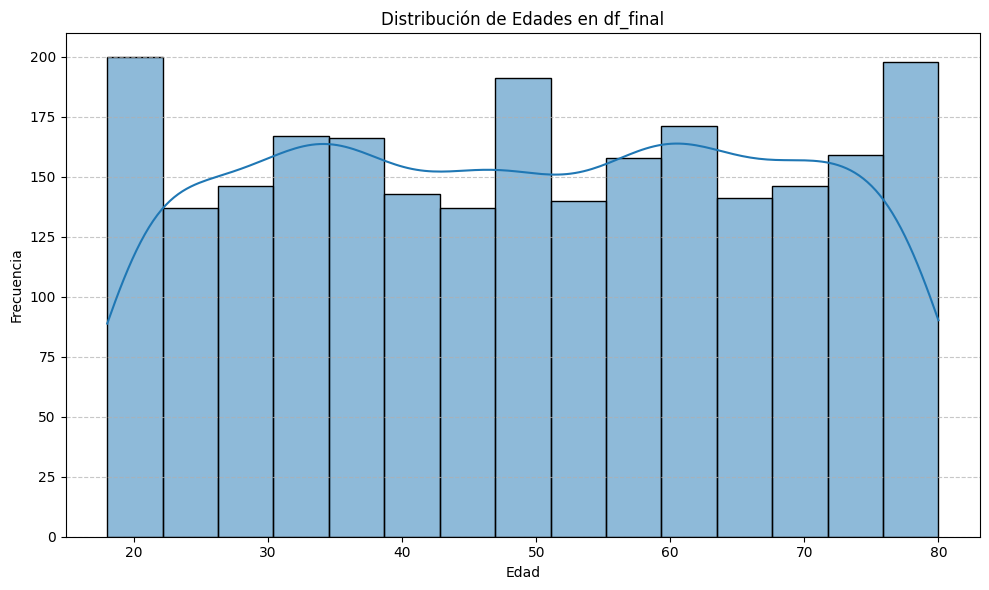

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_final['edad'], bins=15, kde=True)
plt.title('Distribución de Edades en df_final')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

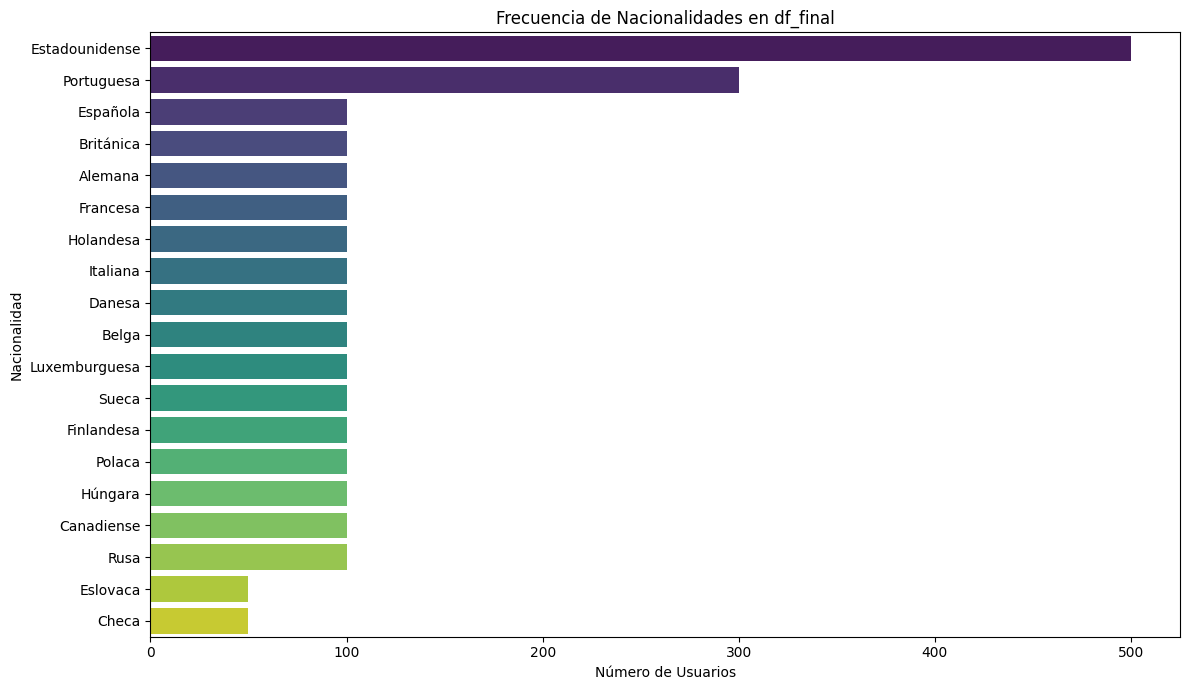

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la frecuencia de cada nacionalidad
nacionalidad_counts = df_final['nacionalidad'].value_counts().reset_index()
nacionalidad_counts.columns = ['Nacionalidad', 'Frecuencia']

# Crear el gráfico de barras
plt.figure(figsize=(12, 7))
sns.barplot(x='Frecuencia', y='Nacionalidad', data=nacionalidad_counts, palette='viridis', hue='Nacionalidad', legend=False)
plt.title('Frecuencia de Nacionalidades en df_final')
plt.xlabel('Número de Usuarios')
plt.ylabel('Nacionalidad')
plt.tight_layout()
plt.show()

In [8]:
display(df_final['nacionalidad'].value_counts())

,count
nacionalidad,
Estadounidense,500
Portuguesa,300
Española,100
Británica,100
Alemana,100
Francesa,100
Holandesa,100
Italiana,100
Danesa,100


In [7]:
display(df_final['nacionalidad'].unique())

array(['Española', 'Alemana', 'Británica', 'Francesa', 'Holandesa',
       'Belga', 'Luxemburguesa', 'Italiana', 'Danesa', 'Finlandesa',
       'Sueca', 'Polaca', 'Checa', 'Eslovaca', 'Húngara', 'Rusa',
       'Canadiense', 'Estadounidense', 'Portuguesa'], dtype=object)

In [27]:
display(df_final.describe())

,id,edad,peso_kg,frecuencia_crema_min
count,2400.000000,2400.000000,2400.000000,2400.000000
mean,1200.500000,49.139167,87.930833,87.356250
std,692.964646,18.291803,22.194736,10.584234
min,1.000000,18.000000,50.000000,45.000000
25%,600.750000,33.000000,69.000000,90.000000
50%,1200.500000,49.000000,89.000000,90.000000
75%,1800.250000,65.000000,107.000000,90.000000
max,2400.000000,80.000000,125.000000,90.000000


In [26]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    2400 non-null   int64 
 1   nombre                2400 non-null   object
 2   apellido              2400 non-null   object
 3   nacionalidad          2400 non-null   object
 4   edad                  2400 non-null   int64 
 5   peso_kg               2400 non-null   int64 
 6   condicion_salud       2400 non-null   object
 7   posicion_recomendada  2400 non-null   object
 8   protocolo_riesgo      2400 non-null   object
 9   fototipo              2400 non-null   object
 10  spf_recomendado       2400 non-null   object
 11  frecuencia_crema_min  2400 non-null   int64 
 12  instruccion_monitor   2400 non-null   object
dtypes: int64(4), object(9)
memory usage: 243.9+ KB


Después de ejecutar la celda anterior, el resultado de `df_final.info()` mostrará la siguiente información:

*   **id**: Tipo entero (`int64`), representa el identificador único de cada usuario.
*   **nombre**: Tipo objeto (`object`), que en Pandas se usa comúnmente para cadenas de texto (strings), indica el nombre del usuario.
*   **apellido**: Tipo objeto (`object`), también para cadenas de texto, indica el apellido del usuario.
*   **nacionalidad**: Tipo objeto (`object`), para cadenas de texto, representa la nacionalidad del usuario.
*   **edad**: Tipo entero (`int64`), indica la edad del usuario en años.
*   **peso_kg**: Tipo entero (`int64`), representa el peso del usuario en kilogramos.
*   **condicion_salud**: Tipo objeto (`object`), para cadenas de texto, describe la condición de salud del usuario.
*   **posicion_recomendada**: Tipo objeto (`object`), para cadenas de texto, indica la posición recomendada para el usuario.
*   **protocolo_riesgo**: Tipo objeto (`object`), para cadenas de texto, señala el nivel de riesgo asociado al usuario.
*   **fototipo**: Tipo objeto (`object`), para cadenas de texto, especifica el fototipo de piel del usuario.
*   **spf_recomendado**: Tipo objeto (`object`), para cadenas de texto, indica el factor de protección solar recomendado.
*   **frecuencia_crema_min**: Tipo entero (`int64`), representa la frecuencia mínima en minutos para aplicar crema solar.
*   **instruccion_monitor**: Tipo objeto (`object`), para cadenas de texto, contiene instrucciones para el monitor relacionadas con el usuario.

Todos los tipos de datos son coherentes con la naturaleza de la información que contienen, siendo números enteros para valores cuantitativos y objetos (strings) para texto descriptivo.

In [4]:
display(df_final.head(5))

,id,nombre,apellido,nacionalidad,edad,peso_kg,condicion_salud,posicion_recomendada,protocolo_riesgo,fototipo,spf_recomendado,frecuencia_crema_min,instruccion_monitor
0,1,Usuario_1,Apellido_Española_1,Española,70,80,Diabetes Tipo II,Centro,Bajo,IV,30,90,Vigilar hidratación y exposición de Española
1,2,Usuario_2,Apellido_Española_2,Española,24,52,Alergia solar severa,Popa,Bajo,III,30,90,Vigilar hidratación y exposición de Española
2,3,Usuario_3,Apellido_Española_3,Española,20,117,Arritmia cardíaca leve y anticoagulado,Centro,Alto,IV,30,90,Vigilar hidratación y exposición de Española
3,4,Usuario_4,Apellido_Española_4,Española,44,98,Asma bronquial,Centro,Bajo,III,30,90,Vigilar hidratación y exposición de Española
4,5,Usuario_5,Apellido_Española_5,Española,80,109,Tendencia alta a la cinetosis (mareo),Popa (Baja),Alto,III,30,90,Vigilar hidratación y exposición de Española
